# Eksperimen Machine Learning — California Housing Dataset
**Nama**: M. Faqih Ibrahim Al-fathi

Notebook ini berisi tahapan eksperimen lengkap mulai dari data loading, EDA, hingga preprocessing untuk dataset California Housing.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Library berhasil diimport!')

Library berhasil diimport!


## 2. Data Loading

In [2]:
# Load California Housing dataset dari sklearn
california = fetch_california_housing(as_frame=True)
df = california.frame

print(f'Dataset Shape: {df.shape}')
print(f'Jumlah Sampel: {df.shape[0]}')
print(f'Jumlah Fitur: {df.shape[1] - 1}')
print(f'Target Variable: MedHouseVal (Median House Value)')
print()
print('Deskripsi Dataset:')
print(california.DESCR[:1000])

Dataset Shape: (20640, 9)
Jumlah Sampel: 20640
Jumlah Fitur: 8
Target Variable: MedHouseVal (Median House Value)

Deskripsi Dataset:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts

In [3]:
# Simpan raw dataset ke CSV
raw_dir = os.path.join('..', 'california_housing_raw')
os.makedirs(raw_dir, exist_ok=True)
df.to_csv(os.path.join(raw_dir, 'california_housing.csv'), index=False)
print('Raw dataset berhasil disimpan!')

Raw dataset berhasil disimpan!


In [4]:
# Tampilkan 5 baris pertama
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
# Tampilkan 5 baris terakhir
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [6]:
# Informasi dataset
print('=== Info Dataset ===')
df.info()

=== Info Dataset ===


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [7]:
# Statistik deskriptif
desc_stats = df.describe()
print('=== Statistik Deskriptif ===')
desc_stats

=== Statistik Deskriptif ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
# Statistik tambahan: skewness dan kurtosis
print('=== Skewness ===')
print(df.skew())
print()
print('=== Kurtosis ===')
print(df.kurtosis())

=== Skewness ===
MedInc          1.646657
HouseAge        0.060331
AveRooms       20.697869
AveBedrms      31.316956
Population      4.935858
AveOccup       97.639561
Latitude        0.465953
Longitude      -0.297801
MedHouseVal     0.977763
dtype: float64

=== Kurtosis ===
MedInc             4.952524
HouseAge          -0.800629
AveRooms         879.353264
AveBedrms       1636.711972
Population        73.553116
AveOccup       10651.010636
Latitude          -1.117760
Longitude         -1.330152
MedHouseVal        0.327870
dtype: float64


### 3.2 Missing Values Analysis

In [9]:
# Cek missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

print('=== Missing Values Analysis ===')
print(missing_df)
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')

=== Missing Values Analysis ===
             Missing Values  Percentage (%)
MedInc                    0             0.0
HouseAge                  0             0.0
AveRooms                  0             0.0
AveBedrms                 0             0.0
Population                0             0.0
AveOccup                  0             0.0
Latitude                  0             0.0
Longitude                 0             0.0
MedHouseVal               0             0.0

Total Missing Values: 0


### 3.3 Distribusi Setiap Fitur

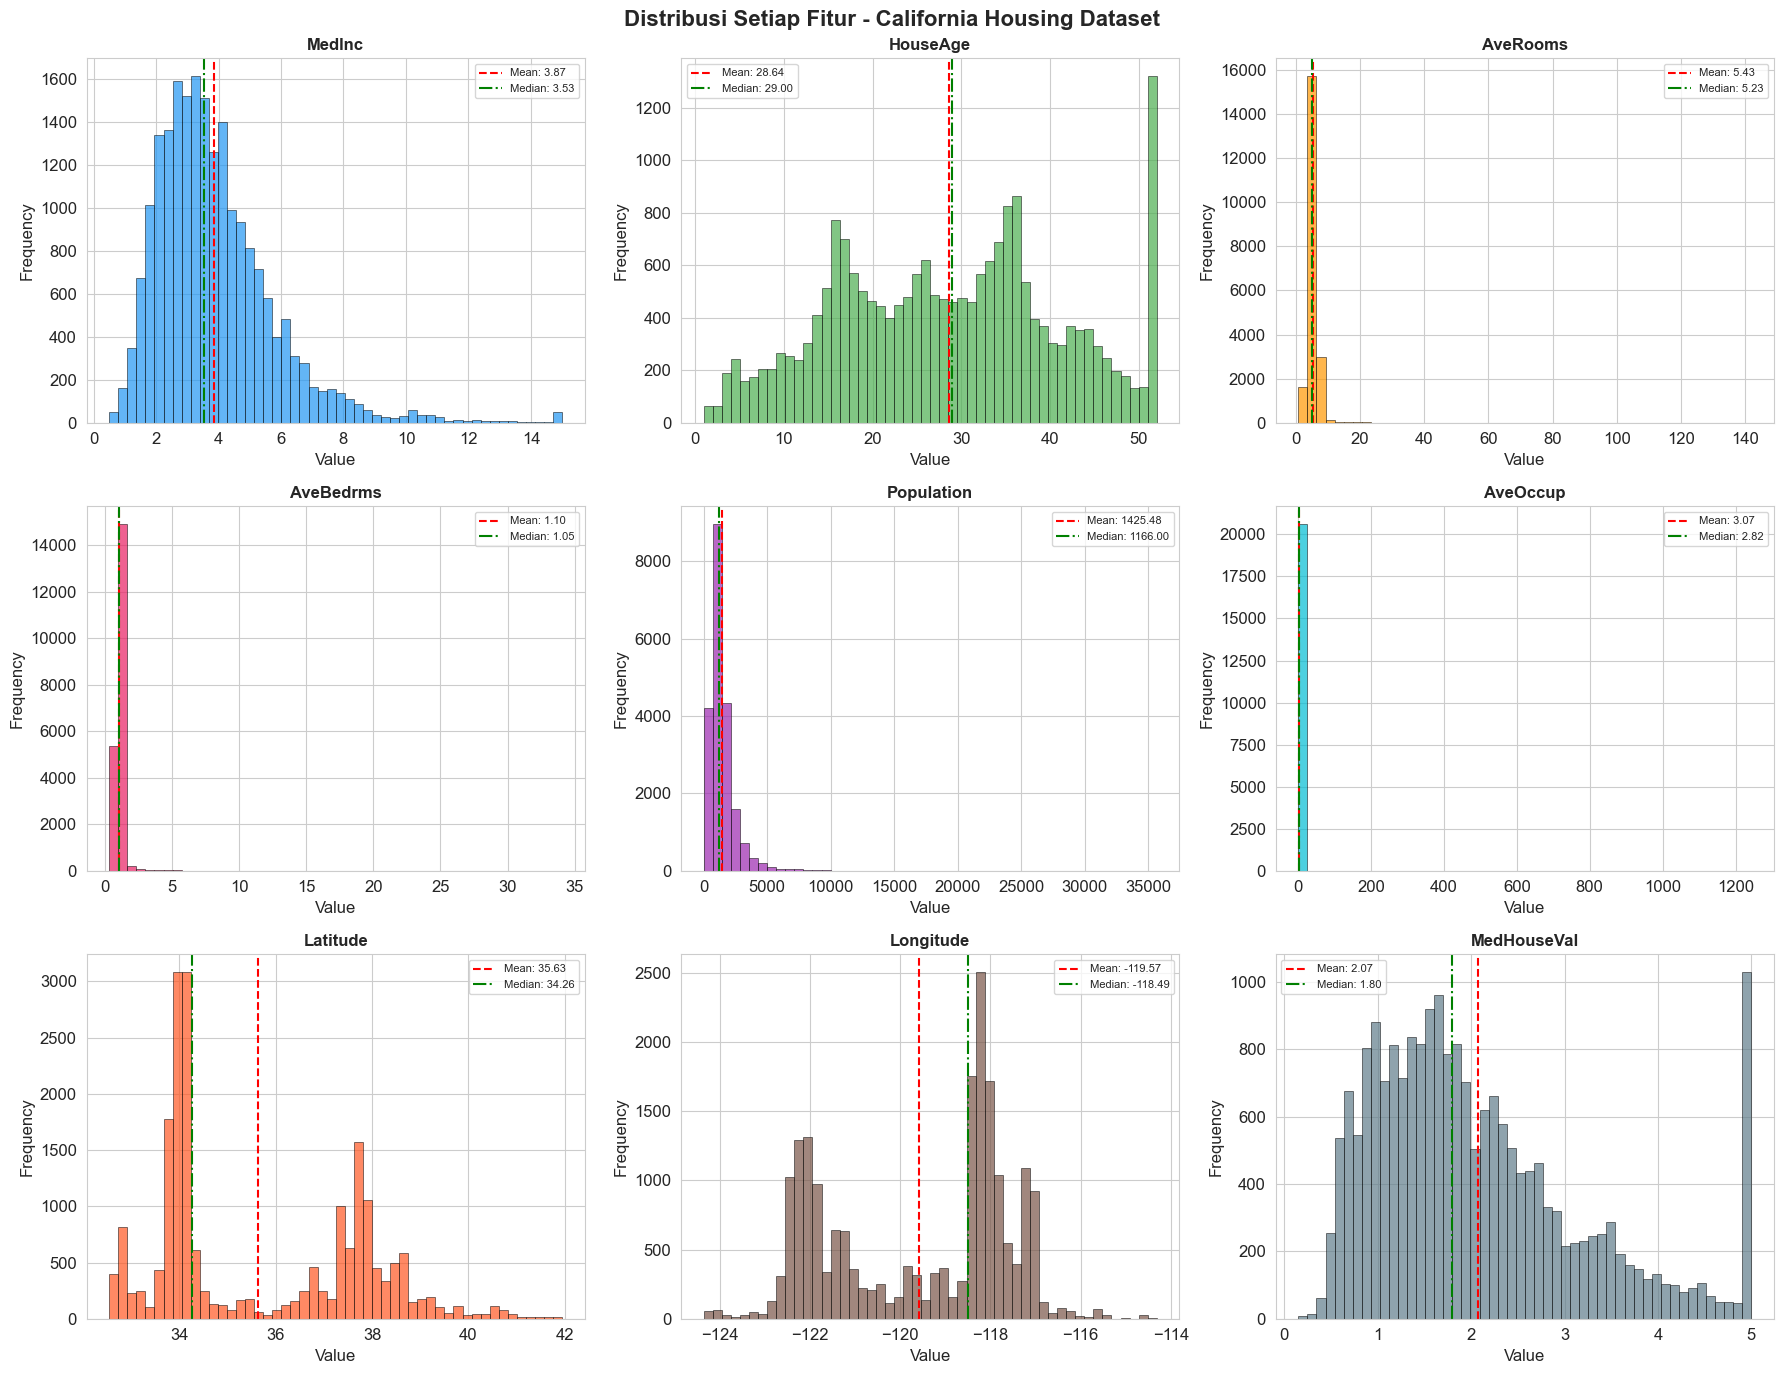

In [10]:
# Histogram distribusi setiap fitur
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Distribusi Setiap Fitur - California Housing Dataset', fontsize=16, fontweight='bold')

columns = df.columns.tolist()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4', '#FF5722', '#795548', '#607D8B']

for idx, (col, color) in enumerate(zip(columns, colors)):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]
    ax.hist(df[col], bins=50, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='-.', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap

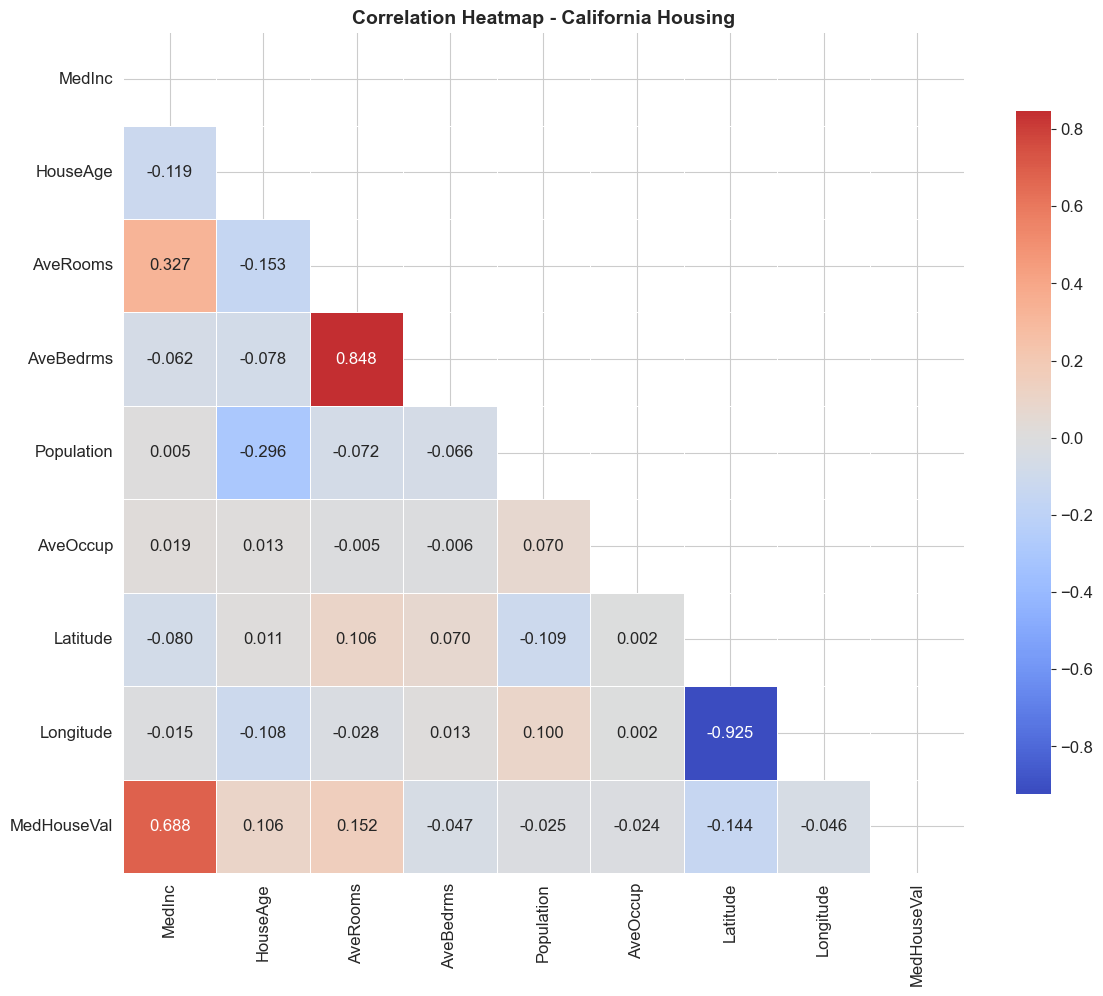


=== Korelasi terhadap Target (MedHouseVal) ===
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: MedHouseVal, dtype: float64


In [11]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Heatmap - California Housing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Korelasi terhadap target
print('\n=== Korelasi terhadap Target (MedHouseVal) ===')
target_corr = correlation_matrix['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
print(target_corr)

### 3.5 Outlier Detection (Boxplot)

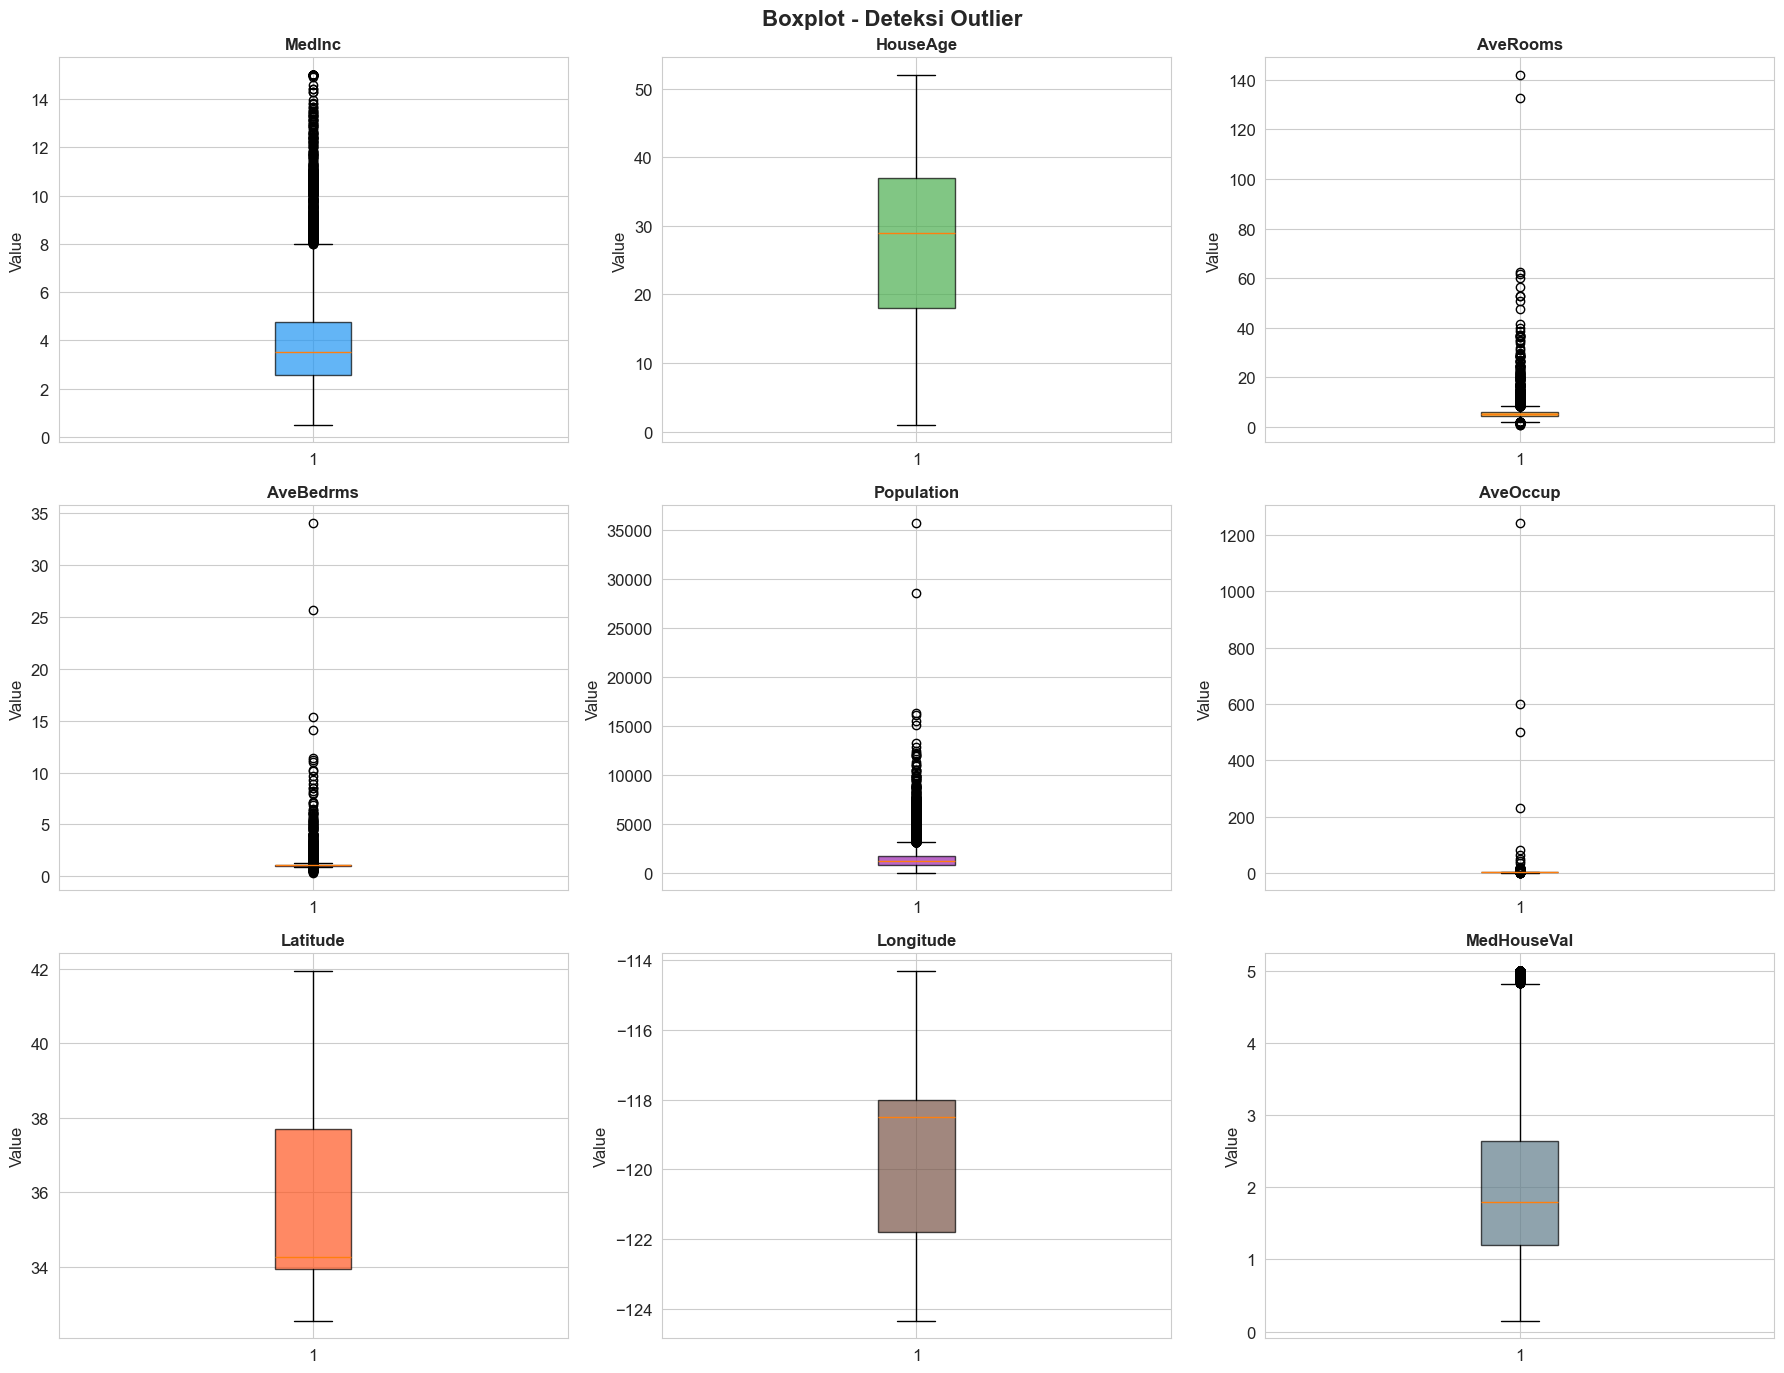

In [12]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Boxplot - Deteksi Outlier', fontsize=16, fontweight='bold')

for idx, col in enumerate(columns):
    row = idx // 3
    col_idx = idx % 3
    ax = axes[row, col_idx]
    bp = ax.boxplot(df[col], patch_artist=True, boxprops=dict(facecolor=colors[idx], alpha=0.7))
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

In [13]:
# Hitung jumlah outlier menggunakan IQR method
print('=== Jumlah Outlier per Fitur (IQR Method) ===')
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)')

=== Jumlah Outlier per Fitur (IQR Method) ===
MedInc: 681 outliers (3.30%)
HouseAge: 0 outliers (0.00%)
AveRooms: 511 outliers (2.48%)
AveBedrms: 1424 outliers (6.90%)
Population: 1196 outliers (5.79%)
AveOccup: 711 outliers (3.44%)
Latitude: 0 outliers (0.00%)
Longitude: 0 outliers (0.00%)
MedHouseVal: 1071 outliers (5.19%)


### 3.6 Scatter Plot: Fitur vs Target

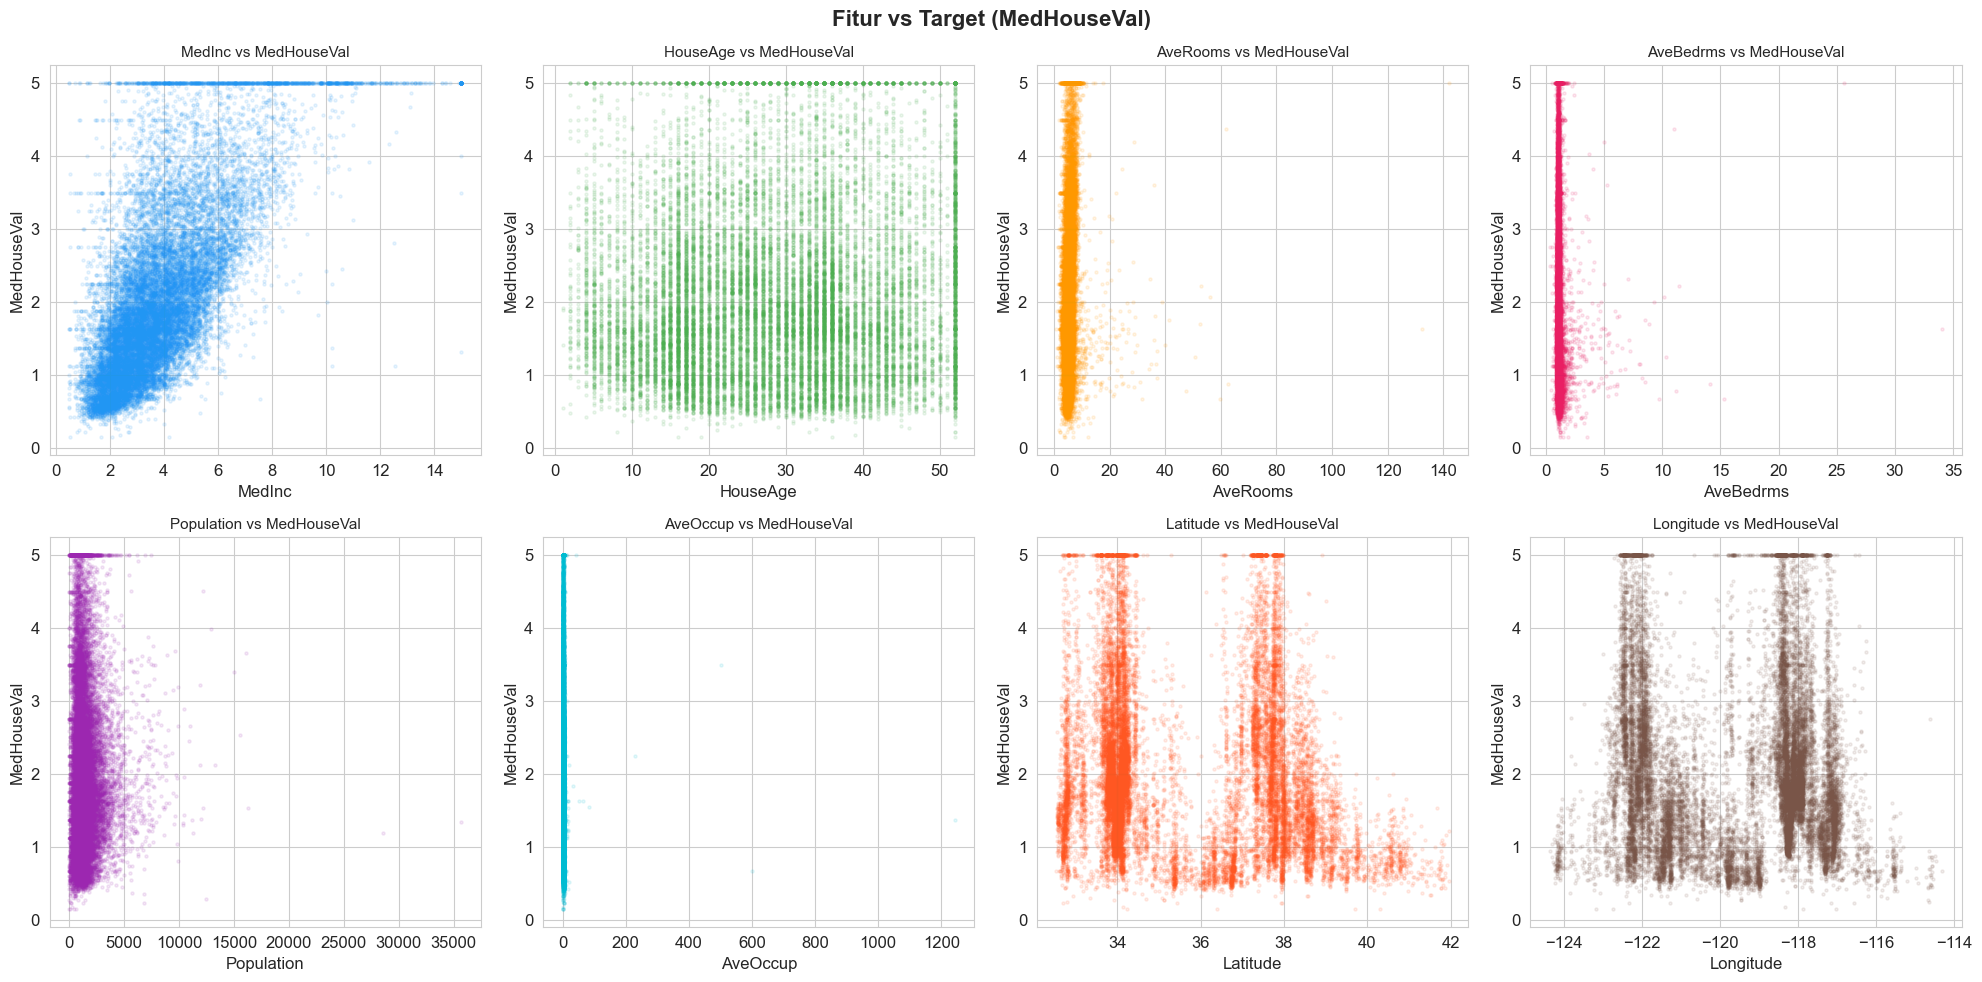

In [14]:
# Scatter plot fitur vs target
features = [col for col in columns if col != 'MedHouseVal']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Fitur vs Target (MedHouseVal)', fontsize=16, fontweight='bold')

for idx, col in enumerate(features):
    row = idx // 4
    col_idx = idx % 4
    ax = axes[row, col_idx]
    ax.scatter(df[col], df['MedHouseVal'], alpha=0.1, s=5, color=colors[idx])
    ax.set_xlabel(col)
    ax.set_ylabel('MedHouseVal')
    ax.set_title(f'{col} vs MedHouseVal', fontsize=11)

plt.tight_layout()
plt.show()

### 3.7 Pair Plot (Subset)

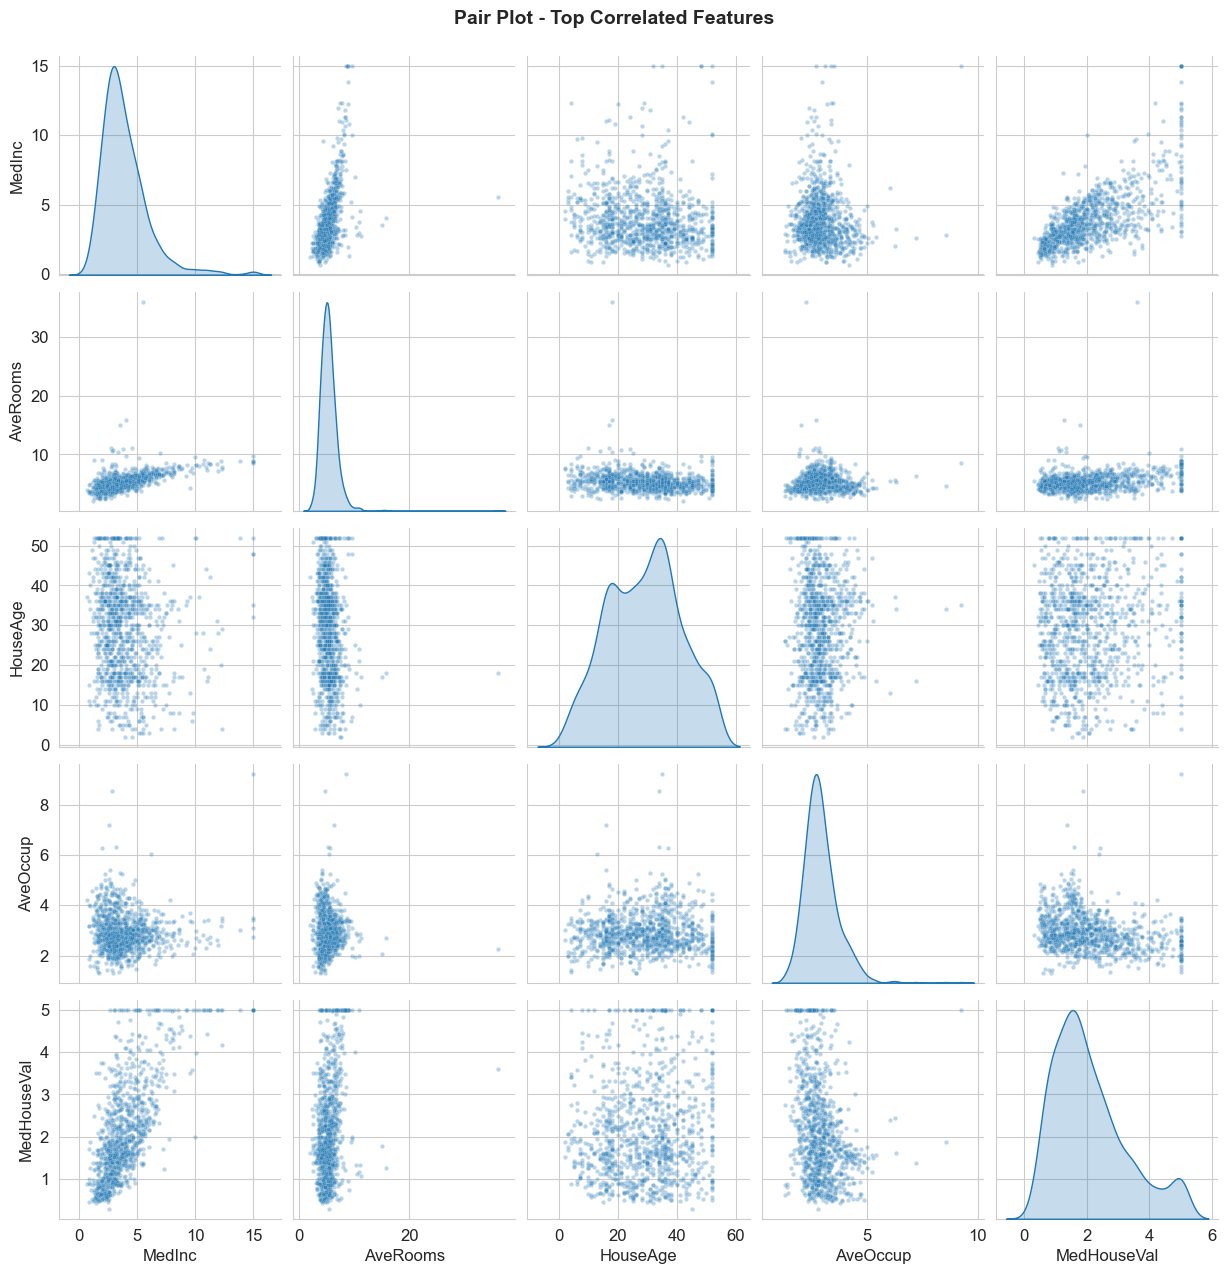

In [15]:
# Pair plot untuk fitur yang paling berkorelasi dengan target
top_features = target_corr.head(4).index.tolist()
top_features.append('MedHouseVal')

sns.pairplot(df[top_features].sample(1000, random_state=42), diag_kind='kde', 
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pair Plot - Top Correlated Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing

### 4.1 Handling Duplicates

In [16]:
# Cek dan hapus duplikat
print(f'Jumlah duplikat sebelum: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Jumlah duplikat setelah: {df.duplicated().sum()}')
print(f'Shape setelah drop duplicates: {df.shape}')

Jumlah duplikat sebelum: 0
Jumlah duplikat setelah: 0
Shape setelah drop duplicates: (20640, 9)


### 4.2 Handling Outliers

In [17]:
# Handling outliers menggunakan IQR capping (winsorization)
# Kita clip nilai outlier ke batas IQR agar tidak kehilangan terlalu banyak data
df_processed = df.copy()

for col in features:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    before_clip = len(df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)])
    df_processed[col] = df_processed[col].clip(lower=lower_bound, upper=upper_bound)
    after_clip = len(df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)])
    
    if before_clip > 0:
        print(f'{col}: {before_clip} outliers di-clip')

print(f'\nShape setelah handling outliers: {df_processed.shape}')

MedInc: 681 outliers di-clip
AveRooms: 511 outliers di-clip
AveBedrms: 1424 outliers di-clip
Population: 1196 outliers di-clip
AveOccup: 711 outliers di-clip

Shape setelah handling outliers: (20640, 9)


### 4.3 Feature Engineering

In [18]:
# Feature Engineering: Membuat fitur baru yang relevan

# Rooms per household
df_processed['RoomsPerHousehold'] = df_processed['AveRooms'] / df_processed['HouseAge'].clip(lower=1)

# Bedrooms ratio (bedrooms per total rooms)
df_processed['BedroomRatio'] = df_processed['AveBedrms'] / df_processed['AveRooms'].clip(lower=0.1)

# Population per household
df_processed['PopPerHousehold'] = df_processed['Population'] / df_processed['AveOccup'].clip(lower=1)

print('Fitur baru yang ditambahkan:')
print('  - RoomsPerHousehold: Rasio jumlah ruangan per usia rumah')
print('  - BedroomRatio: Rasio kamar tidur per total ruangan')
print('  - PopPerHousehold: Populasi per household')
print(f'\nShape setelah feature engineering: {df_processed.shape}')
df_processed.head()

Fitur baru yang ditambahkan:
  - RoomsPerHousehold: Rasio jumlah ruangan per usia rumah
  - BedroomRatio: Rasio kamar tidur per total ruangan
  - PopPerHousehold: Populasi per household

Shape setelah feature engineering: (20640, 12)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomRatio,PopPerHousehold
0,8.013025,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0.170345,0.146591,126.0
1,8.013025,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0.297054,0.155797,1138.0
2,7.257400,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0.159387,0.129516,177.0
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0.111872,0.184458,219.0
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0.120805,0.172096,259.0


### 4.4 Train-Test Split

In [19]:
# Pisahkan features dan target
X = df_processed.drop('MedHouseVal', axis=1)
y = df_processed['MedHouseVal']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nFitur yang digunakan: {list(X.columns)}')

Features shape: (20640, 11)
Target shape: (20640,)

Fitur yang digunakan: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomRatio', 'PopPerHousehold']


In [20]:
# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (16512, 11)
X_test shape: (4128, 11)
y_train shape: (16512,)
y_test shape: (4128,)


### 4.5 Feature Scaling

In [21]:
# Feature scaling menggunakan StandardScaler
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('=== Statistik setelah Scaling (Train) ===')
print(f'Mean (mendekati 0):\n{X_train_scaled.mean().round(6)}')
print(f'\nStd (mendekati 1):\n{X_train_scaled.std().round(6)}')

=== Statistik setelah Scaling (Train) ===
Mean (mendekati 0):
MedInc              -0.0
HouseAge            -0.0
AveRooms            -0.0
AveBedrms           -0.0
Population           0.0
AveOccup            -0.0
Latitude             0.0
Longitude            0.0
RoomsPerHousehold    0.0
BedroomRatio        -0.0
PopPerHousehold     -0.0
dtype: float64

Std (mendekati 1):
MedInc               1.00003
HouseAge             1.00003
AveRooms             1.00003
AveBedrms            1.00003
Population           1.00003
AveOccup             1.00003
Latitude             1.00003
Longitude            1.00003
RoomsPerHousehold    1.00003
BedroomRatio         1.00003
PopPerHousehold      1.00003
dtype: float64


### 4.6 Simpan Dataset Preprocessed

In [22]:
# Gabungkan kembali fitur dan target untuk disimpan
train_data = X_train_scaled.copy()
train_data['MedHouseVal'] = y_train.values

test_data = X_test_scaled.copy()
test_data['MedHouseVal'] = y_test.values

# Simpan ke folder preprocessing
output_dir = 'california_housing_preprocessing'
os.makedirs(output_dir, exist_ok=True)

train_data.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
test_data.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

# Simpan juga dataset gabungan (full preprocessed)
full_preprocessed = pd.concat([train_data, test_data], axis=0)
full_preprocessed.to_csv(os.path.join(output_dir, 'california_housing_preprocessed.csv'), index=False)

print(f'Train data disimpan: {train_data.shape}')
print(f'Test data disimpan: {test_data.shape}')
print(f'Full preprocessed data disimpan: {full_preprocessed.shape}')
print(f'\nFile disimpan di folder: {output_dir}/')

Train data disimpan: (16512, 12)
Test data disimpan: (4128, 12)
Full preprocessed data disimpan: (20640, 12)

File disimpan di folder: california_housing_preprocessing/


### 4.7 Verifikasi Data Preprocessed

In [23]:
# Verifikasi data preprocessed
train_loaded = pd.read_csv(os.path.join(output_dir, 'train.csv'))
test_loaded = pd.read_csv(os.path.join(output_dir, 'test.csv'))

print('=== Verifikasi Data Preprocessed ===')
print(f'Train shape: {train_loaded.shape}')
print(f'Test shape: {test_loaded.shape}')
print(f'\nMissing values (train): {train_loaded.isnull().sum().sum()}')
print(f'Missing values (test): {test_loaded.isnull().sum().sum()}')
print(f'\nDuplikasi (train): {train_loaded.duplicated().sum()}')
print(f'Duplikasi (test): {test_loaded.duplicated().sum()}')
print(f'\nData siap dilatih! ✓')

=== Verifikasi Data Preprocessed ===
Train shape: (16512, 12)
Test shape: (4128, 12)

Missing values (train): 0
Missing values (test): 0

Duplikasi (train): 0
Duplikasi (test): 0

Data siap dilatih! ✓


## 5. Kesimpulan

### Tahapan yang telah dilakukan:
1. **Data Loading**: Dataset California Housing berhasil dimuat dengan 20640 sampel dan 8 fitur.
2. **EDA**:
   - Statistik deskriptif menunjukkan variasi yang cukup besar antar fitur.
   - Tidak ada missing values dalam dataset.
   - Beberapa fitur memiliki distribusi skewed (terutama Population, AveRooms, AveBedrms).
   - Median Income memiliki korelasi tertinggi dengan target.
   - Terdapat outlier pada beberapa fitur.
3. **Preprocessing**:
   - Duplikasi telah dihapus.
   - Outlier di-handle menggunakan IQR capping.
   - Feature engineering menambahkan 3 fitur baru.
   - Train-test split (80:20).
   - Feature scaling menggunakan StandardScaler.
   - Dataset preprocessed disimpan dalam format CSV.

